<a href="https://colab.research.google.com/github/merongedrago/Adversarial_Patches/blob/main/adversarial_attacks_patches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial Attacks - Adversarial Patches
## *prepared by Meron Gedrago*

This notebook is an adoptation of a tutorial by Dr. Brinnae Bent that was originally created by Phillip Lippe.



In [1]:
## Standard libraries
import os
import json
import math
import time
import numpy as np
import scipy.linalg

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial10"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

/tmp/ipython-input-1779675758.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export
INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device cuda:0


We have again a few download statements. This includes both a dataset, and a few pretrained patches we will use later.

In [2]:
import urllib.request
from urllib.error import HTTPError
import zipfile
# Github URL where the dataset is stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial10/"
# Files to download
pretrained_files = [(DATASET_PATH, "TinyImageNet.zip"), (CHECKPOINT_PATH, "patches.zip")]
# Create checkpoint path if it doesn't exist yet
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for dir_name, file_name in pretrained_files:
    file_path = os.path.join(dir_name, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)
        if file_name.endswith(".zip"):
            print("Unzipping file...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(file_path.rsplit("/",1)[0])

## Setup

For our experiments in this notebook, we will use common CNN architectures trained on the ImageNet dataset. Such models are luckily provided by PyTorch's torchvision package, and hence we just need to load the model of our preference.

In [3]:
# Load CNN architecture pretrained on ImageNet
os.environ["TORCH_HOME"] = CHECKPOINT_PATH
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
pretrained_model = pretrained_model.to(device)

# No gradients needed for the network
pretrained_model.eval()
for p in pretrained_model.parameters():
    p.requires_grad = False

To perform adversarial attacks, we also need a dataset to work on. Given that the CNN model has been trained on ImageNet, it is only fair to perform the attacks on data from ImageNet. For this, we provide a small set of pre-processed images from the original ImageNet dataset (note that this dataset is shared under the same [license](http://image-net.org/download-faq) as the original ImageNet dataset). Specifically, we have 5 images for each of the 1000 labels of the dataset. We can load the data below, and create a corresponding data loader.

In [4]:
# Mean and Std from ImageNet
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD = np.array([0.229, 0.224, 0.225])
# No resizing and center crop necessary as images are already preprocessed.
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

# Load dataset and create data loader
imagenet_path = os.path.join(DATASET_PATH, "TinyImageNet/")
assert os.path.isdir(imagenet_path), f"Could not find the ImageNet dataset at expected path \"{imagenet_path}\". " + \
                                     f"Please make sure to have downloaded the ImageNet dataset here, or change the {DATASET_PATH=} variable."
dataset = torchvision.datasets.ImageFolder(root=imagenet_path, transform=plain_transforms)
data_loader = data.DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=8)

# Load label names to interpret the label numbers 0 to 999
with open(os.path.join(imagenet_path, "label_list.json"), "r") as f:
    label_names = json.load(f)

def get_label_index(lab_str):
    assert lab_str in label_names, f"Label \"{lab_str}\" not found. Check the spelling of the class."
    return label_names.index(lab_str)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
def eval_model(dataset_loader, img_func=None):
    tp, tp_5, counter = 0., 0., 0.
    for imgs, labels in tqdm(dataset_loader, desc="Validating..."):
        imgs = imgs.to(device)
        labels = labels.to(device)
        if img_func is not None:
            imgs = img_func(imgs, labels)
        with torch.no_grad():
            preds = pretrained_model(imgs)
        tp += (preds.argmax(dim=-1) == labels).sum()
        tp_5 += (preds.topk(5, dim=-1)[1] == labels[...,None]).any(dim=-1).sum()
        counter += preds.shape[0]
    acc = tp.float().item()/counter
    top5 = tp_5.float().item()/counter
    print(f"Top-1 error: {(100.0 * (1 - acc)):4.2f}%")
    print(f"Top-5 error: {(100.0 * (1 - top5)):4.2f}%")
    return acc, top5

In [6]:
_ = eval_model(data_loader)

Validating...:   0%|          | 0/157 [00:00<?, ?it/s]

Top-1 error: 19.38%
Top-5 error: 4.38%


The ResNet34 achives a decent error rate of 4.3% for the top-5 predictions. Next, we can look at some predictions of the model to get more familiar with the dataset. The function below plots an image along with a bar diagram of its predictions. We also prepare it to show adversarial examples for later applications.

In [7]:
def show_prediction(img, label, pred, K=5, adv_img=None, noise=None):

    if isinstance(img, torch.Tensor):
        # Tensor image to numpy
        img = img.cpu().permute(1, 2, 0).numpy()
        img = (img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        img = np.clip(img, a_min=0.0, a_max=1.0)
        label = label.item()

    # Plot on the left the image with the true label as title.
    # On the right, have a horizontal bar plot with the top k predictions including probabilities
    if noise is None or adv_img is None:
        fig, ax = plt.subplots(1, 2, figsize=(10,2), gridspec_kw={'width_ratios': [1, 1]})
    else:
        fig, ax = plt.subplots(1, 5, figsize=(12,2), gridspec_kw={'width_ratios': [1, 1, 1, 1, 2]})

    ax[0].imshow(img)
    ax[0].set_title(label_names[label])
    ax[0].axis('off')

    if adv_img is not None and noise is not None:
        # Visualize adversarial images
        adv_img = adv_img.cpu().permute(1, 2, 0).numpy()
        adv_img = (adv_img * NORM_STD[None,None]) + NORM_MEAN[None,None]
        adv_img = np.clip(adv_img, a_min=0.0, a_max=1.0)
        ax[1].imshow(adv_img)
        ax[1].set_title('Adversarial')
        ax[1].axis('off')
        # Visualize noise
        noise = noise.cpu().permute(1, 2, 0).numpy()
        noise = noise * 0.5 + 0.5 # Scale between 0 to 1
        ax[2].imshow(noise)
        ax[2].set_title('Noise')
        ax[2].axis('off')
        # buffer
        ax[3].axis('off')

    if abs(pred.sum().item() - 1.0) > 1e-4:
        pred = torch.softmax(pred, dim=-1)
    topk_vals, topk_idx = pred.topk(K, dim=-1)
    topk_vals, topk_idx = topk_vals.cpu().numpy(), topk_idx.cpu().numpy()
    ax[-1].barh(np.arange(K), topk_vals*100.0, align='center', color=["C0" if topk_idx[i]!=label else "C2" for i in range(K)])
    ax[-1].set_yticks(np.arange(K))
    ax[-1].set_yticklabels([label_names[c] for c in topk_idx])
    ax[-1].invert_yaxis()
    ax[-1].set_xlabel('Confidence')
    ax[-1].set_title('Predictions')

    plt.show()
    plt.close()

Let's visualize a few images below:

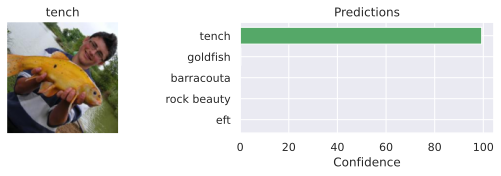

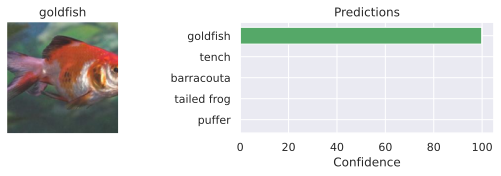

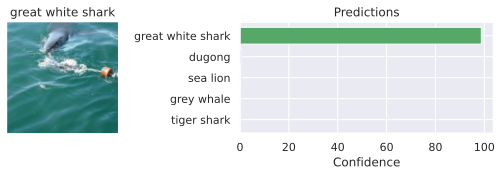

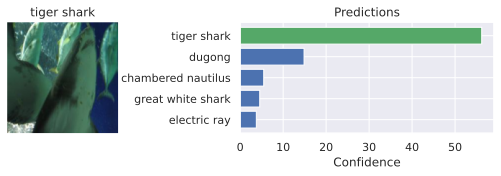

In [8]:
exmp_batch, label_batch = next(iter(data_loader))
with torch.no_grad():
    preds = pretrained_model(exmp_batch.to(device))
for i in range(1,17,5):
    show_prediction(exmp_batch[i], label_batch[i], preds[i])

The bar plot on the right shows the top-5 predictions of the model with their class probabilities. We denote the class probabilities with "confidence" as it somewhat resembles how confident the network is that the image is of one specific class. Some of the images have a highly peaked probability distribution, and we would expect the model to be rather robust against noise for those. However, we will see below that this is not always the case. Note that all of the images are of fish because the data loader doesn't shuffle the dataset. Otherwise, we would get different images every time we run the notebook, which would make it hard to discuss the results on the static version.

### Adversarial Patches

In addition to the tutorial, I wanted to ensure that the patch performed well at different angles, so I introduced random rotations during training. I also experimented with random resizing to vary the patch size throughout training. However, this approach led to worse performance, likely due to the model’s inability to converge with both random angle and random size variations. As a result, I decided to retain only the random angle augmentation and increased the number of training epochs from 5 to 15 to allow the loss to converge.

*GPT 5 was used on 11/11/2025 4:05 am to rephrase the following so it is easier to read*

In [9]:
import torchvision.transforms.functional as F
import numpy as np
import torch # Import torch

def place_patch(img, patch, num_spots=1, random_rotation=True, random_scale=False, scale_range=(0.5, 1.0), rotation_angles=None):
    patched_img = img.clone()
    # Define the list of rotation angles if not provided
    rotation_angles_list = [0,  90,  180,  270, ] if rotation_angles is None else rotation_angles


    for i in range(patched_img.shape[0]):
        current_patch = patch_forward(patch)

        # scale = np.random.uniform(scale_range[0], scale_range[1])
        # Calculate new size, maintaining aspect ratio. Ensure size is at least 1x1
        # new_h = max(1, int(current_patch.shape[1] * scale))
        # new_w = max(1, int(current_patch.shape[2] * scale))
        # current_patch = F.resize(current_patch, size=(new_h, new_w))

        # Select random angle from the specified list and cast to int
        angle = int(np.random.choice(rotation_angles_list))
        current_patch = F.rotate(current_patch, angle, fill=0)
        # the above two lines code snippet was generated by Gemini on 11/11/2025 on 4 pm

        # Ensure patch fits within image dimensions after potential scaling and rotation
        patch_h, patch_w = current_patch.shape[1:]
        img_h, img_w = patched_img.shape[2:]


        # Calculate offsets based on the actual size of the transformed patch
        h_offset = np.random.randint(0, img_h - patch_h + 1)
        w_offset = np.random.randint(0, img_w - patch_w + 1)


        # Place the transformed patch using its actual dimensions
        patched_img[i, :, h_offset : h_offset + patch_h, w_offset : w_offset + patch_w] = current_patch
    return patched_img

In [10]:
TENSOR_MEANS, TENSOR_STD = torch.FloatTensor(NORM_MEAN)[:,None,None], torch.FloatTensor(NORM_STD)[:,None,None]
def patch_forward(patch):
    # Map patch values from [-infty,infty] to ImageNet min and max
    patch = (torch.tanh(patch) + 1 - 2 * TENSOR_MEANS) / (2 * TENSOR_STD)
    return patch

In [11]:
def eval_patch(model, patch, val_loader, target_class):
    model.eval()
    tp, tp_5, counter = 0., 0., 0.
    with torch.no_grad():
        for img, img_labels in tqdm(val_loader, desc="Validating...", leave=False):
            # For stability, place the patch at 4 random locations per image, and average the performance
            for _ in range(4):
                patch_img = place_patch(img, patch)
                patch_img = patch_img.to(device)
                img_labels = img_labels.to(device)
                pred = model(patch_img)
                # In the accuracy calculation, we need to exclude the images that are of our target class
                # as we would not "fool" the model into predicting those
                tp += torch.logical_and(pred.argmax(dim=-1) == target_class, img_labels != target_class).sum()
                tp_5 += torch.logical_and((pred.topk(5, dim=-1)[1] == target_class).any(dim=-1), img_labels != target_class).sum()
                counter += (img_labels != target_class).sum()
    acc = tp/counter
    top5 = tp_5/counter
    return acc, top5

In [12]:
def patch_attack(model, target_class, patch_size=64, num_epochs=15):
    # Leave a small set of images out to check generalization
    # In most of our experiments, the performance on the hold-out data points
    # was as good as on the training set. Overfitting was little possible due
    # to the small size of the patches.
    train_set, val_set = torch.utils.data.random_split(dataset, [4500, 500])
    train_loader = data.DataLoader(train_set, batch_size=32, shuffle=True, drop_last=True, num_workers=8)
    val_loader = data.DataLoader(val_set, batch_size=32, shuffle=False, drop_last=False, num_workers=4)

    # Create parameter and optimizer
    if not isinstance(patch_size, tuple):
        patch_size = (patch_size, patch_size)
    patch = nn.Parameter(torch.zeros(3, patch_size[0], patch_size[1]), requires_grad=True)
    optimizer = torch.optim.SGD([patch], lr=1e-1, momentum=0.8)
    loss_module = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
        t = tqdm(train_loader, leave=False)
        for img, _ in t:
            img = place_patch(img, patch)
            img = img.to(device)
            pred = model(img)
            labels = torch.zeros(img.shape[0], device=pred.device, dtype=torch.long).fill_(target_class)
            loss = loss_module(pred, labels)
            optimizer.zero_grad()
            loss.mean().backward()
            optimizer.step()
            t.set_description(f"Epoch {epoch}, Loss: {loss.item():4.2f}")

    # Final validation
    acc, top5 = eval_patch(model, patch, val_loader, target_class)

    return patch.data, {"acc": acc.item(), "top5": top5.item()}

In [13]:
# Load evaluation results of the pretrained patches
json_results_file = os.path.join(CHECKPOINT_PATH, "patch_results.json")
json_results = {}
if os.path.isfile(json_results_file):
    with open(json_results_file, "r") as f:
        json_results = json.load(f)

# If you train new patches, you can save the results via calling this function
def save_results(patch_dict):
    result_dict = {cname: {psize: [t.item() if isinstance(t, torch.Tensor) else t
                                   for t in patch_dict[cname][psize]["results"]]
                           for psize in patch_dict[cname]}
                   for cname in patch_dict}
    with open(os.path.join(CHECKPOINT_PATH, "patch_results.json"), "w") as f:
        json.dump(result_dict, f, indent=4)

Additionally, we implemented a function to train and evaluate patches across a list of classes and patch sizes. I selected peacock, strawberry, and coyote as target classes because they exhibit strong contrast in both texture and color. Similar to the original notebook, after observing that the largest patch size of $64\times64$ pixels performed best, I retained those patches for the final version presented here.

*GPT 5 was used at 3:05 pm on 11/03/2025 to ingest the list of 1000 objects in the imagenet to ask categories of the elemnts and to find ones that are colorful and texture rich*

In [14]:
def get_patches(class_names, patch_sizes):
    result_dict = dict()

    # Loop over all classes and patch sizes
    for name in class_names:
        result_dict[name] = dict()
        for patch_size in patch_sizes:
            c = label_names.index(name)
            file_name = os.path.join(CHECKPOINT_PATH, f"{name}_{patch_size}_patch.pt")
            # Load patch if pretrained file exists, otherwise start training
            if not os.path.isfile(file_name):
                patch, val_results = patch_attack(pretrained_model, target_class=c, patch_size=patch_size, num_epochs=15) # Changed num_epochs to 15
                print(f"Validation results for {name} and {patch_size}:", val_results)
                torch.save(patch, file_name)
            else:
                patch = torch.load(file_name)
            # Load evaluation results if exist, otherwise manually evaluate the patch
            if name in json_results:
                results = json_results[name][str(patch_size)]
            else:
                results = eval_patch(pretrained_model, patch, data_loader, target_class=c)

            # Store results and the patches in a dict for better access
            result_dict[name][patch_size] = {
                "results": results,
                "patch": patch
            }

    return result_dict

In [16]:
json_results

{'peacock': {'64': [0.9414914846420288, 0.9970470666885376]},
 'strawberry': {'64': [0.8313813805580139, 0.9840340614318848]},
 'coyote': {'64': [0.8563563823699951, 0.9876376390457153]}}

In [18]:
class_names = ['peacock','strawberry', 'coyote']

patch_sizes = [64]

patch_dict = get_patches(class_names, patch_sizes)


In [19]:
save_results(patch_dict) # Uncomment if you add new class names and want to save the new results

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import tabulate
from IPython.display import display, HTML
import os # Import os module

def show_table(top_1=True):
    i = 0 if top_1 else 1
    table = [[name] + [f"{(100.0 * patch_dict[name][psize]['results'][i]):4.2f}%" for psize in patch_sizes]
             for name in class_names]
    display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Class name"] + [f"Patch size {psize}x{psize}" for psize in patch_sizes])))

def save_results(patch_dict, save_path=None): # Add optional save_path argument
    result_dict = {cname: {psize: [t.item() if isinstance(t, torch.Tensor) else t
                                   for t in patch_dict[cname][psize]["results"]]
                           for psize in patch_dict[cname]}
                   for cname in patch_dict}
    if save_path is None: # Use default path if no save_path is provided
      save_path = os.path.join(CHECKPOINT_PATH, "patch_results.json")
    else: # Create directory if it doesn't exist
      os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, "w") as f:
        json.dump(result_dict, f, indent=4)
    print(f"Results saved to: {save_path}") # Print confirmation message

Now you can call `save_results` with a path in your Google Drive after mounting it. For example:

In [22]:
# Example of saving to Google Drive
save_results(patch_dict, save_path='/content/drive/MyDrive/patch_results.json')

Results saved to: /content/drive/MyDrive/patch_results.json


Before looking at the quantitative results, we can actually visualize the patches.

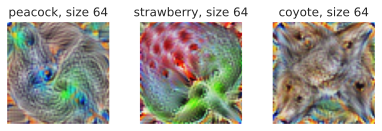

In [36]:
def show_patches():
    fig, ax = plt.subplots(len(patch_sizes), len(class_names), figsize=(len(class_names)*2.2, len(patch_sizes)*2.2))
    for c_idx, cname in enumerate(class_names):
        for p_idx, psize in enumerate(patch_sizes):
            patch = patch_dict[cname][psize]["patch"]
            patch = (torch.tanh(patch) + 1) / 2 # Parameter to pixel values
            patch = patch.cpu().permute(1, 2, 0).numpy()
            patch = np.clip(patch, a_min=0.0, a_max=1.0)
            if len(patch_sizes) == 1:
                ax[c_idx].imshow(patch)
                ax[c_idx].set_title(f"{cname}, size {psize}")
                ax[c_idx].axis('off')
            else:
                ax[p_idx][c_idx].imshow(patch)
                ax[p_idx][c_idx].set_title(f"{cname}, size {psize}")
                ax[p_idx][c_idx].axis('off')
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()
show_patches()

In [24]:
import matplotlib.pyplot as plt
import os

def save_individual_patches(patch_dict, save_dir):
    """Saves each individual patch from the patch_dict as a PNG image."""
    os.makedirs(save_dir, exist_ok=True) # Create save directory if it doesn't exist

    for class_name in patch_dict:
        for patch_size in patch_dict[class_name]:
            patch = patch_dict[class_name][patch_size]["patch"]
            patch_img = (torch.tanh(patch.data) + 1) / 2 # Parameter to pixel values
            patch_img = patch_img.cpu().permute(1, 2, 0).numpy()
            patch_img = np.clip(patch_img, a_min=0.0, a_max=1.0)

            filename = f"{class_name}_{patch_size}.png"
            save_path = os.path.join(save_dir, filename)
            plt.imsave(save_path, patch_img)
            print(f"Saved patch for {class_name} {patch_size} to {save_path}")

save_individual_patches(patch_dict, '/content/drive/MyDrive/patch_images')

Saved patch for peacock 64 to /content/drive/MyDrive/patch_images/peacock_64.png
Saved patch for strawberry 64 to /content/drive/MyDrive/patch_images/strawberry_64.png
Saved patch for coyote 64 to /content/drive/MyDrive/patch_images/coyote_64.png


We can see that the patches have some resemblence to the original documents especially for the Coyote and Strawberry patches.



In [25]:
%%html
<!-- Some HTML code to increase font size in the following table -->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [26]:
import tabulate
from IPython.display import display, HTML

def show_table(top_1=True):
    i = 0 if top_1 else 1
    table = [[name] + [f"{(100.0 * patch_dict[name][psize]['results'][i]):4.2f}%" for psize in patch_sizes]
             for name in class_names]
    display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Class name"] + [f"Patch size {psize}x{psize}" for psize in patch_sizes])))

First, we will create a table of top-1 accuracy, meaning that how many images have been classified with the target class as highest prediction?

In [27]:
show_table(top_1=True)

Class name,Patch size 64x64
peacock,94.15%
strawberry,83.14%
coyote,85.64%




Let's also take a look at the top-5 accuracy:

In [28]:
show_table(top_1=False)

Class name,Patch size 64x64
peacock,99.70%
strawberry,98.40%
coyote,98.76%


From the above, we can see that the top-5 accuracy is over 98% for all three patches, with the different rotation in training meaning that our patch should be robust if it is placed anywhere on an image and at more angles.

Finally, let's create some example visualizations of the patch attack in action.

In [29]:
def perform_patch_attack(patch):
    patch_batch = exmp_batch.clone()
    patch_batch = place_patch(patch_batch, patch)
    with torch.no_grad():
        patch_preds = pretrained_model(patch_batch.to(device))
    for i in range(1,17,5):
        show_prediction(patch_batch[i], label_batch[i], patch_preds[i])

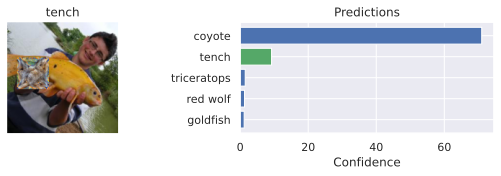

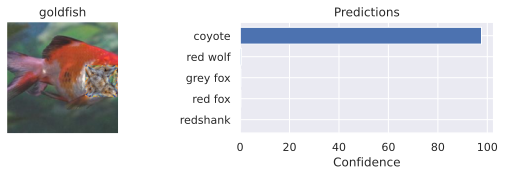

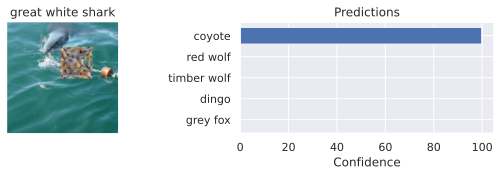

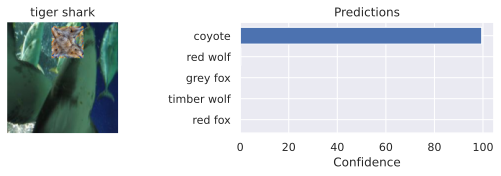

In [31]:
perform_patch_attack(patch_dict['coyote'][64]['patch'])

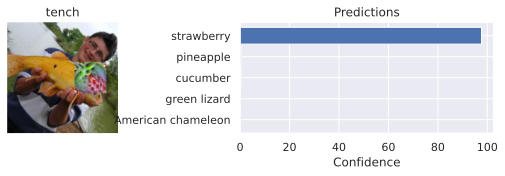

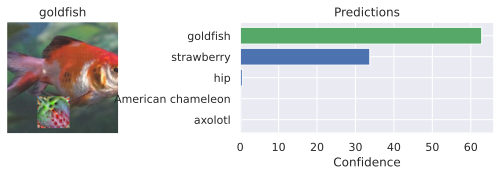

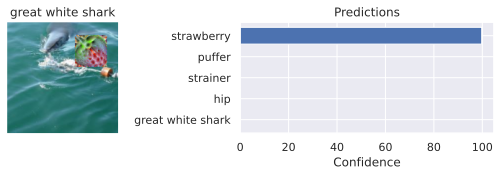

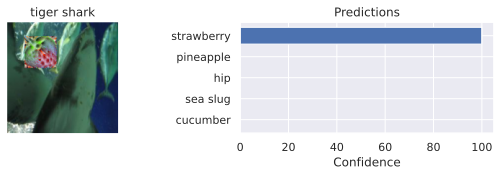

In [32]:
perform_patch_attack(patch_dict['strawberry'][64]['patch'])

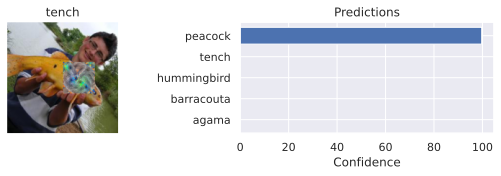

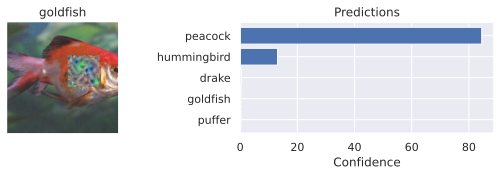

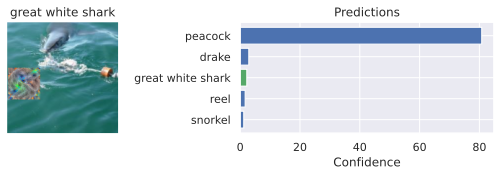

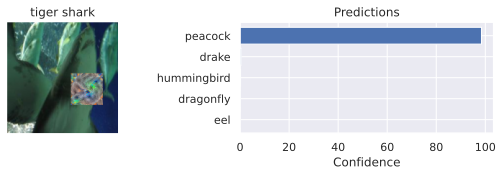

In [33]:
perform_patch_attack(patch_dict['peacock'][64]['patch'])

The only time the patch doesnt lead to the top-1 prediction is when we put the Strawberry patch on the goldfish, however, the Strawberry prediction is the second one.

## Placing two patches on the same image

In addition to the above, I was curious to look at patches patches that have similar accuracy on the same image. Out of the three patches, Coyote and Strawberry had similar top-1 and top-5 accuracies. Therefore, I placed the patches on the images as below.

In [34]:
def double_patch_attack(patch1, patch2):
    patch_batch = exmp_batch.clone()
    patch_batch = place_patch(patch_batch, patch1)
    patch_batch = place_patch(patch_batch, patch2)
    with torch.no_grad():
        patch_preds = pretrained_model(patch_batch.to(device))
    for i in range(1,17,5):
        show_prediction(patch_batch[i], label_batch[i], patch_preds[i])

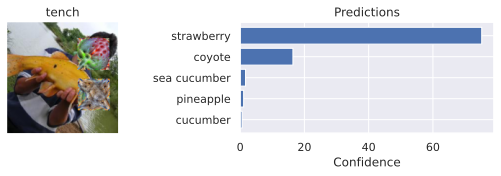

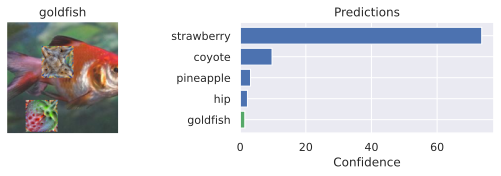

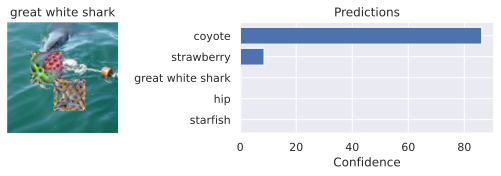

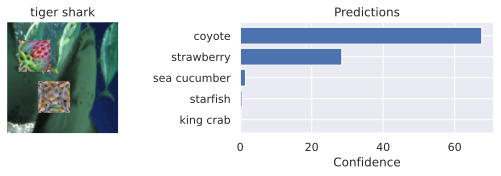

In [35]:
double_patch_attack(patch_dict['strawberry'][64]['patch'],patch_dict['coyote'][64]['patch'])

As shown above, Coyote and Strawberry consistently appear as the top two predictions across all images, even though the images themselves are entirely different. Specifically, Strawberry is the top-1 prediction for two out of the four images, while Coyote is top-1 for the remaining two. Although the exact reason for this behavior is unclear, a possible explanation is the similarity in color between the image backgrounds and the Strawberry class. For instance, both the Goldfish and Tench images are classified as Strawberry, likely due to their colorful backgrounds. In contrast, the Tiger Shark and Great White Shark images have more muted tones, which may contribute to Coyote being predicted as the top-1 class in those cases.

*GPT 5 was used on 11/03/2025 4:05 am to rephrase the following so it is easier to read*

## References

This tutorial was originally created by Phillip Lippe.
[![View notebooks on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/Adversarial_Attacks.ipynb)
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/Adversarial_Attacks.ipynb)  

[1] Goodfellow, Ian J., Jonathon Shlens, and Christian Szegedy. "Explaining and harnessing adversarial examples." ICLR 2015.

[2] Hendrik Metzen, Jan, et al. "Universal adversarial perturbations against semantic image segmentation." Proceedings of the IEEE International Conference on Computer Vision. 2017.

[3] Anant Jain. "Breaking neural networks with adversarial attacks." [Blog post](https://towardsdatascience.com/breaking-neural-networks-with-adversarial-attacks-f4290a9a45aa) 2019.